# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

<div>
    
|    Group   |           1          |
|------------|----------------------|
| Junhan Chong  |        6153283       |
| Jack Bergmann  |        6200850       |
| Madhav Tiwari  |        6141870       |
| Ben Chen  |        6543405       |

#### Imports

In [4]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [5]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        # find all possible actions for the particular state that the agent is in
        valid_as = agent.get_valid_actions(maze)
        # choose an action from the list of valid actions randomly, with uniform distribution
        chosen_action = np.random.choice(valid_as)
        # take the chosen action
        return chosen_action

        


    def e_greedy(self, agent: Agent, maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        # find all possible actions for the particular state that the agent is in
        valid_as = agent.get_valid_actions(maze)
        s = agent.get_state(maze)

        # find the corresponding q values for the possible actions
        q_vals = [self.q_table.get_q(s, a) for a in valid_as]

        # find the actions with largest q value(s)
        max_q = np.max(q_vals)
        max_q_actions = [a for a, q in zip(valid_as, q_vals) if q == max_q]

        chosen_action = None
        # with probability of 1 - eps, select randomly from actions with the largest q values
        if (np.random.uniform() > eps):
            chosen_action = np.random.choice(max_q_actions)
        # with probability of eps, select randomly from the list of possible actions
        else:
            not_max = [a for a in valid_as if a not in max_q_actions]
            if len(not_max) == 0:
                chosen_action = np.random.choice(valid_as)
            else:
                chosen_action = np.random.choice(not_max)
        # take the chosen action
        return chosen_action



    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration and as the temperature declines over time,
        exploitation is favoured. 
        """
        # find all possible actions for the particular state that the agent is in
        valid_as = agent.get_valid_actions(maze)
        s = agent.get_state(maze)

        # find the corresponding q values for the possible actions
        q_vals = [self.q_table.get_q(s, a) for a in valid_as]
        # subtract max q val for numerical stability
        q_vals = np.array(q_vals)
        q_vals = q_vals - np.max(q_vals)

        # guard against zero-division
        if temperature <= 0:
            # apply greedy if temperature is zero
            max_q = np.max(q_vals)
            max_q_actions = [a for a, q in zip(valid_as, q_vals) if q == max_q]
            chosen_action = np.random.choice(max_q_actions)
            return chosen_action

        # calculate exp(Q(s,a) / T) for all possible actions
        boltzmann_probs = np.exp(q_vals / temperature)

        # find the sum and divide each term by the sum
        boltzmann_probs /= np.sum(boltzmann_probs)

        
        # choose an action with the boltzmann probabilities as the weights
        chosen_action = np.random.choice(valid_as, p=boltzmann_probs)

        # take the chosen action
        return chosen_action

<div>

**Explain what you did, including the initial selection of the hyper-parameter values. How do you deal with exploration/exploitation tradeoff?**

All three strategies start with finding the valid actions that the agent can take at its current state. This is because the probability of choosing an invalid action should be zero in all given strategies.

For random exploration, I chose an action randomly based on an uniform distribution between the available actions. There are no hyper-parameters for this strategy because all decisions are made with a random uniform probability between actions. Therefore, this exploration strategy would be used initially to maximise exploration while neglecting exploitation.

For $\epsilon$-greedy exploration, I found the corresponding Q values for the possible actions to use for the greedy property of this strategy. With the Q values, we can simply choose the action with the highest associated Q value by definition. However, this approach would only use exploitation without the use of exploration since at any given point, the agent deterministically chooses what action to take. Therefore, we introduce a hyperparameter: $\epsilon$, to introduce exploration. Increasing $\epsilon$ increases exploration by increasing the probability of a random action being chosen, naturally decreasing exploitation as well. Therefore, we must find a suitable value of $\epsilon$ to achieve a good balance of exploitation and exploration in order to avoid convergence at a local optima, while keeping the learning relatively fast and efficient.

For Boltzmann exploration, we assign weights to the different actions to be used as the probability distribution. After finding the corresponding Q values for all possible actions, we use the softmax formula to assign probabilities for the actions. However, just by using the softmax function to assign weights for probability means we cannot tune the strategy to encourage or discourage more exploitation. Therefore, we introduce a hyperparameter $\tau$ (true Boltzmann exploration) which influences the probability of all possible actions. As we increase $\tau$, the probabilities decrease exponentially to its magnitude (because of the exponentiation). Hence, decreasing $\tau$ leads to more exploitation (as the higher Q value actions would be assigned a larger the probability relative to the lower Q value actions) while increasing it will even out the probability distribution towards uniform distribution; As $\tau$ approaches the limit of 0, the approach becomes greedier and greedier, while $T$ approaching infinity would make the strategy choose actions from a uniform distribution.

In practice, we should choose hyperparameters that encourage exploration (large $\epsilon$, large $\tau$) initially, so the agent can learn about the environment and map out a sensible Q table. As the agent explores, we can decrease the hyperparameters to favour more and more exploitation.

Hence, we can use Boltzmann exploration with a large value of $\tau$ initially to encourage exploration, then gradually 'decay' the temperature over each episode until it reaches a threshold to increase exploitation gradually. Since we have four actions per state, with a reward of 10 at the terminal state (initially), our Q values will not be larger than 10. Therefore, we can choose a relatively small value for the temperature, such as $\tau = 1$. Then we can use a fixed percentage value such as 0.99 to slowly decay the temperature over episodes. These hyper-parameters can be optimised during training (with the validation set) to maximise efficiency while minimising the risk of early convergence at a local optima.

#### Question 2

In [6]:
# Create a Maze instance.
easy_maze = Maze("./../data/easy_maze.txt")
easy_maze.set_reward(x = 9, y = 9, reward = 10)
easy_maze.set_terminal(x = 9, y = 9)

def main_no_learn(maze, n_episodes = 300, alpha = 0.1, discount = 0.9, decay = 0.99, temperature = 1):
    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []

    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": 0.7, "gamma": 0.9}
    # learner = QLearning(q_table, params)

    
    # repeat exploration #n_episodes amount of time
    for episode in tqdm(range(n_episodes)):
        # put agent at the start
        agent.reset()

        #counter to check progress
        steps = 0
        total_r = 0

        # explore until terminal state
        while (agent.get_state(maze).done == False):
            # one exploration step
            current_state = agent.get_state(maze)
            chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            next_state, r, done = agent.step(chosen_action, maze)

            ## updating Q table is the learner's job ##

            # variables for Q table update calculations
            # q_old = q_table.get_q(current_state, chosen_action)
            # q_max_new = np.max([q_table.get_q(next_state, a) for a in agent.get_valid_actions(maze)])

            # update Q table
            # q_table.set_q(current_state, chosen_action, 
                        # q_old + alpha * (r + discount * q_max_new - q_old))
            
            # re-assign/increment control variables
            current_state = next_state
            total_r += r
            steps += 1
        
        # decay the temperature every episode
        temperature *= decay

        # append progress variables to progress tracker
        episode_rewards.append(total_r)
        episode_lengths.append(steps)


<div>

**Explain the cycle in your report.**

The cycle consists of three steps until the agent reaches a terminal state:
1. **Take action step:** We decide on the action for the agent to take. We used the Boltzmann strategy, with an initial temperature of 1.0. We then take the chosen action, getting the new state and reward for the action (at the particular state) as a return value. <br>
*\<This step is necessary for the agent to explore the environment\>*
2. **Update Q table:** We take the Q values of the initial state and action that we've chosen, as well as the Q values for max state-action value for the next state. Using these, we calculate the new Q value for the initial state-action pair. <br>
*\<This step is necessary to learn the environment. Q table is what is used to exploit efficient paths\>*
3. **Update states and reward metrics:** We then update the current state variable to the new position of the agent, as well as incrementing the rewards and step count to use as a performance metric. <br>
*\<This step is necessary to evaluate progress and allow for a cycle\>*

This cycle can be repeated until the agent reaches the terminal state, at which a new episode will start. These three steps are sufficient for a complete trial/episode (agent exploring from the start to terminal state) as it can explore the environment and learn from it (Q table). Repeating this cycle over the episodes will lead to a convergence in the Q value according to the **Stochastic Approximation Theory**. Then we can improve the policy based on the values from the Q table.

#### Question 3

In [7]:
def main_early_stop_no_learn(maze, n_episodes = 300, decay = 0.99, temperature = 1, early_stop = 30000):
    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []

    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)

    # Create a QTable
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    
    # Create an ExplorationStrategy
    exploration_strategy = ExplorationStrategy(q_table)

    # global step tracker
    total_steps = 0
    episodes = 0

    # repeat exploration #n_episodes amount of time
    for episode in range(n_episodes):
        # put agent at the start
        agent.reset()

        #counter to check progress
        steps = 0
        total_r = 0

        # explore until terminal state
        while (agent.get_state(maze).done == False):
            if (total_steps >= early_stop):
                break
            ## STEP 1: TAKE STEP ##
            current_state = agent.get_state(maze)
            chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            next_state, r, done = agent.step(chosen_action, maze)

            ## STEP 2: UPDATE Q TABLE / LEARN ##
            
            ## STEP 3: RECORD STATE AND REWARDS ##
            # re-assign/increment control variables
            current_state = next_state
            total_r += r
            steps += 1
            total_steps += 1
        
        # decay the temperature every episode
        temperature *= decay

        # append progress variables to progress tracker
        episode_rewards.append(total_r)
        episode_lengths.append(steps)

        episodes += 1
        print(f"{ steps } steps at episode { episodes }")

        if (total_steps >= early_stop):
            print(f"{ total_steps } steps reached. Terminating current episode.")
            print(f"Stopped at episode number: { episodes }")
            break
        
    return episode_lengths

In [8]:
main_early_stop_no_learn(easy_maze)

2778 steps at episode 1
7124 steps at episode 2
11898 steps at episode 3
3278 steps at episode 4
1406 steps at episode 5
884 steps at episode 6
2632 steps at episode 7
30000 steps reached. Terminating current episode.
Stopped at episode number: 7


[2778, 7124, 11898, 3278, 1406, 884, 2632]

<div>

We introduced a global step counter that gets incremented at every step. Since there are two loops, with the outer loop iterating over the episodes and the inner loop iterating over the cycles, we include a break statement in both blocks to ensure that the cycle and the episode are both terminated once reaching 30,000 steps. To verify, we included two simple print statements printing some meta data about the runs (number of episodes, total steps).

We can also note from the steps per episode, that there is a very large variance between episodes, ranging from 100 to over 10,000 steps per episode. There also doesn't seem to be a clear decrease in the number of steps per episode. This is expected as we have not implemented the learning function.

#### Question 4

In [9]:
toy_maze = Maze("./../data/toy_maze.txt")
toy_maze.set_reward(x = 9, y = 9, reward = 10)
toy_maze.set_terminal(x = 9, y = 9)

def run_multiple_no_learn(maze, n_runs = 10, early_stop = 30000):
    all_runs = []

    for i in range(n_runs):
        episode_lengths = main_early_stop_no_learn(
            maze, early_stop
        )
        all_runs.append(episode_lengths)

    return all_runs


def plot_average_episode_lengths(all_runs, difficulty, learning_type = "None"):
    # find max number of episodes across runs
    max_len = max(len(run) for run in all_runs)

    # pad runs with NaN so they all have equal length
    padded_runs = []
    for run in all_runs:
        padded = run + [np.nan] * (max_len - len(run))
        padded_runs.append(padded)

    padded_runs = np.array(padded_runs)

    # compute mean ignoring NaNs
    avg_lengths = np.nanmean(padded_runs, axis=0)
    stds = np.nanstd(padded_runs, axis=0)
    epochs = np.arange(len(avg_lengths)) # for axis labelling with no .5s

    # plot
    plt.figure()
    plt.plot(epochs, avg_lengths, label="Average")
    plt.fill_between(
        epochs,
        np.maximum(avg_lengths - stds, 0),
        avg_lengths + stds,
        alpha=0.3
    )
    plt.xlabel("Episode")
    plt.ylabel("Average Steps per Episode")
    if learning_type == "None":
        plt.title(f"Average episode length over runs in { difficulty } maze")
    else:
        plt.title(f"Average episode length over runs in { difficulty } maze using {learning_type}")
    plt.show()




1538 steps at episode 1
694 steps at episode 2
2254 steps at episode 3
994 steps at episode 4
392 steps at episode 5
1240 steps at episode 6
552 steps at episode 7
388 steps at episode 8
1222 steps at episode 9
368 steps at episode 10
3470 steps at episode 11
802 steps at episode 12
824 steps at episode 13
392 steps at episode 14
1948 steps at episode 15
996 steps at episode 16
1632 steps at episode 17
1484 steps at episode 18
1320 steps at episode 19
1142 steps at episode 20
926 steps at episode 21
110 steps at episode 22
920 steps at episode 23
1286 steps at episode 24
1062 steps at episode 25
532 steps at episode 26
662 steps at episode 27
424 steps at episode 28
426 steps at episode 29
30000 steps reached. Terminating current episode.
Stopped at episode number: 29
190 steps at episode 1
900 steps at episode 2
2966 steps at episode 3
2674 steps at episode 4
1948 steps at episode 5
936 steps at episode 6
3434 steps at episode 7
170 steps at episode 8
3506 steps at episode 9
222 steps

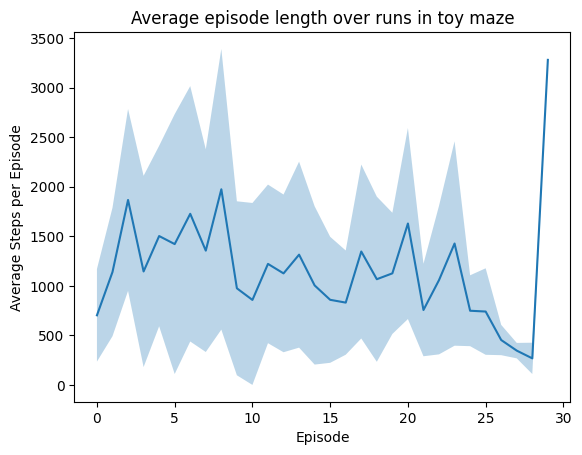

1122 steps at episode 1
2158 steps at episode 2
3928 steps at episode 3
656 steps at episode 4
548 steps at episode 5
276 steps at episode 6
230 steps at episode 7
924 steps at episode 8
874 steps at episode 9
3106 steps at episode 10
1726 steps at episode 11
3968 steps at episode 12
10484 steps at episode 13
30000 steps reached. Terminating current episode.
Stopped at episode number: 13
386 steps at episode 1
1210 steps at episode 2
366 steps at episode 3
1298 steps at episode 4
122 steps at episode 5
608 steps at episode 6
1718 steps at episode 7
5534 steps at episode 8
1522 steps at episode 9
1042 steps at episode 10
760 steps at episode 11
756 steps at episode 12
4216 steps at episode 13
384 steps at episode 14
7038 steps at episode 15
2144 steps at episode 16
630 steps at episode 17
266 steps at episode 18
30000 steps reached. Terminating current episode.
Stopped at episode number: 18
200 steps at episode 1
7850 steps at episode 2
5092 steps at episode 3
2076 steps at episode 4
53

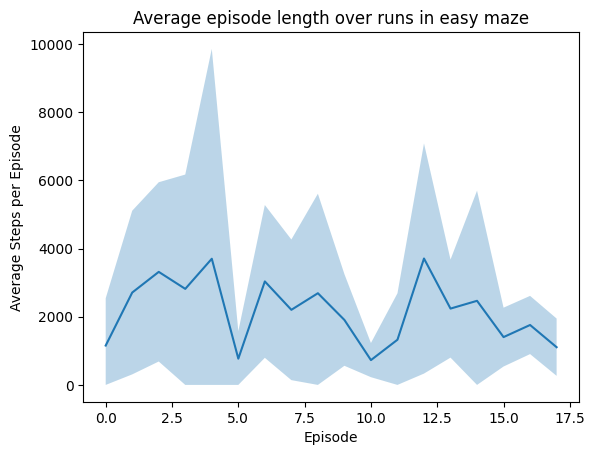

In [10]:
plot_average_episode_lengths(run_multiple_no_learn(toy_maze, early_stop=100000), "toy")
plot_average_episode_lengths(run_multiple_no_learn(easy_maze, early_stop=300000), "easy")

<div>

The plot shows that there is no clear downwards trend for each consecutive episodes in the average over all runs. This indicates that the agent does not take more efficient paths over episode progression due to the lack of learning (updating of the Q table).
Towards the ends of the runs, the average is calculated from fewer values than earlier because some runs might terminate earlier. Therefore, there may be an increased volatility that makes it look like the plot is showing certain trends.

#### Question 5

In [11]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        # variables for Q table update calculations
        q_old = self.q_table.get_q(state, action)
        q_max_new = np.max([self.q_table.get_q(next_state, a) for a in possible_actions])

        # update Q table
        self.q_table.set_q(state, action, 
                    q_old + self.params["lr"] * (reward + self.params["gamma"] * q_max_new - q_old))

In [12]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        # variables for Q table update calculations
        q_old = self.q_table.get_q(state, action)
        q_new = self.q_table.get_q(next_state, next_action)

        # update Q table
        self.q_table.set_q(state, action, 
                    q_old + self.params["lr"] * (reward + self.params["gamma"] * q_new - q_old))

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

#### Question 6

In [13]:
def main_early_stop(maze, n_episodes = 300, params = {"lr": 0.7, "gamma": 0.9}, decay = 0.99, eps = 0.0, temperature = 1, early_stop = 30000, q_learning=True, strategy="boltzmann", out_text=False): 
    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []

    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)

    # Create a QTable
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    
    # Create an ExplorationStrategy
    exploration_strategy = ExplorationStrategy(q_table)

    # Create a learner
    if (q_learning):
        learner = QLearning(q_table, params)
    else:
        learner = SARSA(q_table, params)

    # global step tracker
    total_steps = 0
    episodes = 0

    # repeat exploration #n_episodes amount of time
    for episode in range(n_episodes):
        # put agent at the start
        agent.reset()

        #counter to check progress
        steps = 0
        total_r = 0

        # explore until terminal state
        while (agent.get_state(maze).done == False):
            if (total_steps >= early_stop):
                break
            # one exploration step
            current_state = agent.get_state(maze)
            if strategy == "random":
                chosen_action = exploration_strategy.random(agent, maze)
            elif strategy == "e_greedy":
                chosen_action = exploration_strategy.e_greedy(agent, maze, eps)
            elif strategy == "boltzmann":
                chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            else:
                chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            next_state, r, done = agent.step(chosen_action, maze)
                
            # variables for Q table update calculations
            if (q_learning):
                learner.learn(agent.get_valid_actions(maze), current_state, chosen_action, next_state, r, done)
            else:
                next_action = exploration_strategy.boltzmann(agent, maze, temperature)
                learner.learn(current_state, chosen_action, next_state, next_action, r, done)

            # re-assign/increment control variables
            current_state = next_state
            total_r += r
            steps += 1
            total_steps += 1
        
        # decay the temperature every episode
        temperature *= decay

        # append progress variables to progress tracker
        episode_rewards.append(total_r)
        episode_lengths.append(steps)

        episodes += 1
        if out_text: print(f"{ steps } steps at episode { episodes }")

        if (total_steps >= early_stop):
            if out_text:
                print(f"{ total_steps } steps reached. Terminating current episode.")
                print(f"Stopped at episode number: { episodes }")
            break
        
    return episode_lengths

def run_multiple_q(maze, n_runs = 10, params = {"lr": 0.7, "gamma": 0.9}, decay = 0.99, eps = 0.1, temperature = 1, early_stop = 30000, q_learning=True, strategy="boltzmann", out_text=False):
    all_runs = []

    for i in range(n_runs):
        episode_lengths = main_early_stop(
            maze, early_stop = early_stop, q_learning = q_learning, strategy = strategy, eps = eps, temperature = temperature, decay = decay, params = params, out_text = out_text
        )
        all_runs.append(episode_lengths)

    return all_runs


4482 steps at episode 1
3046 steps at episode 2
4220 steps at episode 3
1578 steps at episode 4
1906 steps at episode 5
4118 steps at episode 6
22586 steps at episode 7
2072 steps at episode 8
3750 steps at episode 9
2380 steps at episode 10
706 steps at episode 11
2028 steps at episode 12
224 steps at episode 13
746 steps at episode 14
806 steps at episode 15
72 steps at episode 16
642 steps at episode 17
140 steps at episode 18
2624 steps at episode 19
128 steps at episode 20
62 steps at episode 21
272 steps at episode 22
42 steps at episode 23
132 steps at episode 24
1412 steps at episode 25
52 steps at episode 26
38 steps at episode 27
2386 steps at episode 28
50 steps at episode 29
76 steps at episode 30
54 steps at episode 31
38 steps at episode 32
30 steps at episode 33
26 steps at episode 34
186 steps at episode 35
24 steps at episode 36
50 steps at episode 37
26 steps at episode 38
26 steps at episode 39
42 steps at episode 40
28 steps at episode 41
86 steps at episode 42
34 s

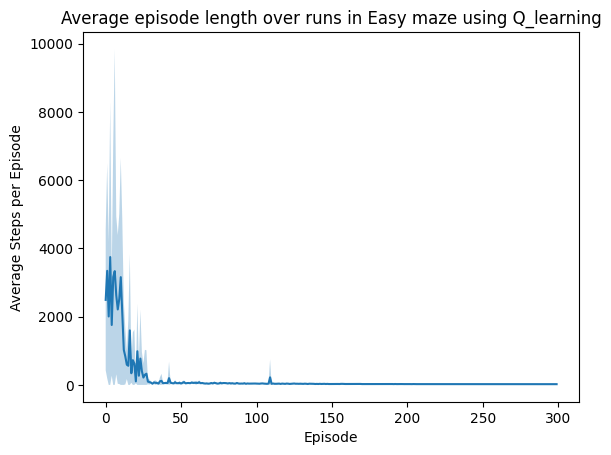

1882 steps at episode 1
408 steps at episode 2
650 steps at episode 3
1166 steps at episode 4
1972 steps at episode 5
3542 steps at episode 6
1368 steps at episode 7
2206 steps at episode 8
208 steps at episode 9
1276 steps at episode 10
938 steps at episode 11
4770 steps at episode 12
2226 steps at episode 13
3316 steps at episode 14
768 steps at episode 15
4256 steps at episode 16
152 steps at episode 17
5858 steps at episode 18
1930 steps at episode 19
3250 steps at episode 20
1774 steps at episode 21
74 steps at episode 22
1766 steps at episode 23
1830 steps at episode 24
96 steps at episode 25
70 steps at episode 26
3420 steps at episode 27
154 steps at episode 28
66 steps at episode 29
212 steps at episode 30
72 steps at episode 31
270 steps at episode 32
2188 steps at episode 33
112 steps at episode 34
284 steps at episode 35
24 steps at episode 36
42 steps at episode 37
250 steps at episode 38
788 steps at episode 39
5958 steps at episode 40
26 steps at episode 41
34 steps at e

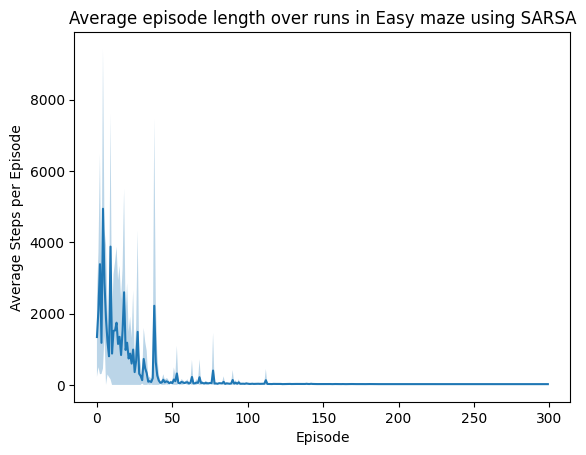

In [14]:
plot_average_episode_lengths(run_multiple_q(easy_maze, early_stop=500000, out_text=True), "Easy", learning_type="Q_learning")
plot_average_episode_lengths(run_multiple_q(easy_maze, early_stop=500000, q_learning = False, out_text=True), "Easy", learning_type="SARSA")

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 7

<div style="background-color:#f1be3e">

_Write your answer here._

### 2.2 Optimization
#### Question 8

In [16]:
def plot_comparison(all_data_dict, title, max_episodes = 100):
    plt.figure()
    for label, all_runs in all_data_dict.items():
        max_len = max(len(run) for run in all_runs)
        padded = [run + [np.nan] * (max_len - len(run)) for run in all_runs]
        padded = np.array(padded)
        avg = np.nanmean(padded, axis=0)
        std = np.nanstd(padded, axis=0)
        epochs = np.arange(len(avg))

        plt.plot(epochs, avg, label=label)
        plt.fill_between(epochs, np.maximum(avg - std, 0), avg + std, alpha=0.2)

    plt.xlabel("Episode")
    plt.ylabel("Average Steps per Episode")
    plt.title(title)
    plt.ylim(0, 5000)
    plt.xlim(0, max_episodes)
    plt.legend()
    plt.show()

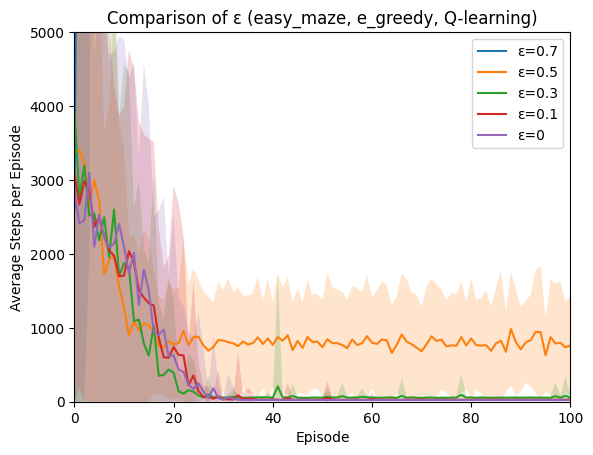

In [ ]:
all_data = {}

for eps in [0.7, 0.5, 0.3, 0.1, 0]:
    all_data[f"ε={eps}"] = run_multiple_q(easy_maze, early_stop=100000, strategy="e_greedy", eps=eps, n_runs=100)

plot_comparison(all_data, "Comparison of ε (easy_maze, e_greedy, Q-learning)")

As shown in the plot, ε=0.7 fails to converge within the given episodes, as the high exploration rate prevents the agent from effectively exploiting the learned Q-table. The remaining four values (ε=0, 0.1, 0.3, 0.5) converge at a comparable rate in the early episodes. However, their long-term performance differs noticeably.

ε=0, 0.1, and 0.3 all converge to a very low and stable number of steps, with ε=0 achieving the lowest. ε=0.5 shows signs of faster convergence in the first 10 episodes compared to the other values, likely because its higher exploration rate allows the agent to stumble upon a more optimal path earlier. Similarly, ε=0.3 also shows slightly faster initial convergence than ε=0 and 0.1. However, both ε=0.3 and ε=0.5 ultimately converge to a higher number of steps, as their exploration rates remain too high for this environment to allow full exploitation.

Overall, lower ε values lead to better final performance in this environment. Since the easy maze is not complex enough to require extensive exploration to avoid local optima, even a small amount of exploration is sufficient to find the optimal path.

#### Question 9

A low value of ε favours exploitation, meaning the agent is more likely to choose the action with the greatest estimated Q-value, which enables the agent to converge more quickly and find a better path. However, given that it rarely considers other options that can result in higher long-term returns, the agent runs the risk of being trapped in a local optimum.

A high value of ε favours exploration, and the agent takes random actions more frequently. This lowers the risk of converging to a local optimum, as the agent is more likely to discover potentially better paths. However, excessive exploration slows down convergence and may prevent the agent from effectively exploiting its learned knowledge, leading to a higher average number of steps per episode even after many episodes.

The key challenge is finding a balance point where the agent explores enough to avoid local optima, while still being able to exploit its knowledge to converge to a low step count. The optimal value of ε depends on the complexity of the environment. In simple environments like the easy maze, a low ε is sufficient. In more complex environments, a higher ε may be necessary to avoid getting stuck in a local optimum.

#### Question 10

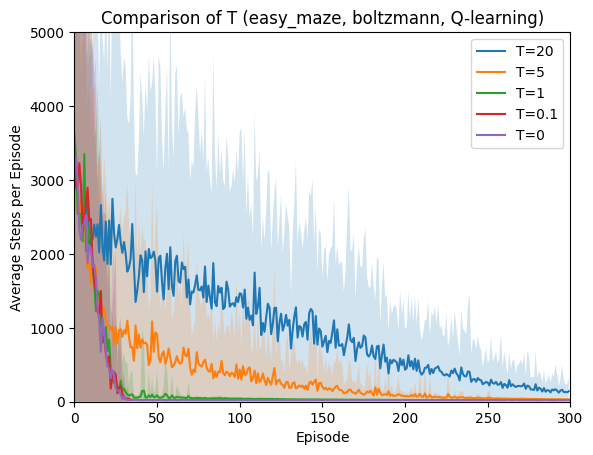

In [ ]:
all_data = {}

for t in [20, 5, 1, 0.1, 0]:
    all_data[f"T={t}"] = run_multiple_q(easy_maze, early_stop=1000000, strategy="boltzmann", temperature=t, n_runs=100)

plot_comparison(all_data, "Comparison of T (easy_maze, boltzmann, Q-learning)", max_episodes=300)

As shown in the plot, higher T values (T=20, T=5) result in very slow convergence, as the action selection is closer to a uniform random distribution, preventing the agent from effectively exploiting its learned Q-table. Despite the temperature decay gradually shifting the agent towards exploitation over time, T=20 and T=5 still fail to outperform T=1 within 300 episodes.

Lower T values (T=0, T=0.1, T=1) converge quickly and reach very low average steps per episode. T=0, being fully greedy, achieves the lowest step count in this environment.

The trade-off for Boltzmann exploration lies in balancing computational cost against the complexity of the environment. In a simple environment like the easy maze, a low T value is sufficient, as the agent needs very little exploration to find the optimal path. In more complex environments, a higher T value may be necessary to avoid local optima, but this comes at the cost of significantly more computational resources and episodes before convergence. Therefore, the optimal T must be chosen based on the complexity of the environment and the available computational budget.


#### Question 11

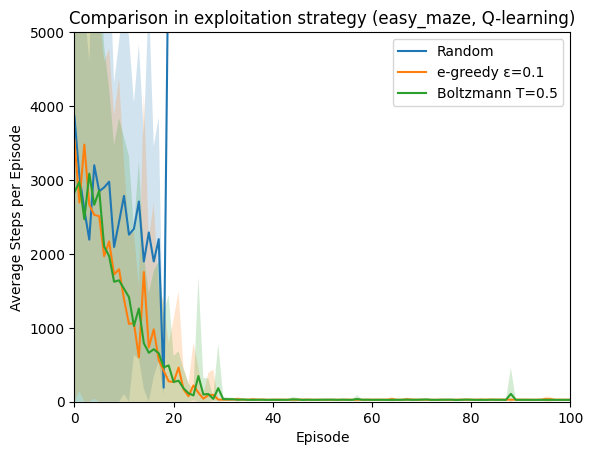

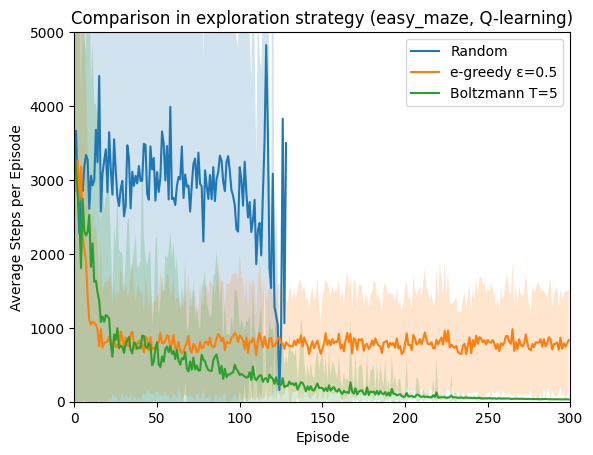

In [325]:
data_low_value = {
    "Random": run_multiple_q(easy_maze, strategy="random", n_runs=100),
    "e-greedy ε=0.1": run_multiple_q(easy_maze, strategy="e_greedy", eps=0.1, n_runs=100),
    "Boltzmann T=0.5": run_multiple_q(easy_maze, strategy="boltzmann", temperature=0.5, n_runs=100),
}

data_high_value = {
    "Random": run_multiple_q(easy_maze, early_stop=300000, strategy="random", n_runs=100),
    "e-greedy ε=0.5": run_multiple_q(easy_maze, early_stop=300000, strategy="e_greedy", eps=0.5, n_runs=100),
    "Boltzmann T=5": run_multiple_q(easy_maze, early_stop=300000, strategy="boltzmann", temperature=5, n_runs=100),
}

plot_comparison(data_low_value, "Comparison in exploitation strategy (easy_maze, Q-learning)")
plot_comparison(data_high_value, "Comparison in exploration strategy (easy_maze, Q-learning)", max_episodes=300)

Two comparisons are shown as one with low exploration settings (e-greedy ε=0.1, Boltzmann T=0.5) and one with high exploration settings (e-greedy ε=0.5, Boltzmann T=5), both compared against random exploration.

In the low exploration setting, all three strategies perform similarly, with e-greedy and Boltzmann both converging quickly to a low step count. The random strategy converges the slowest, as it makes no use of the learned Q-values at any point.

In the high exploration setting, a clear difference emerges between e-greedy and Boltzmann. e-greedy converges quickly initially but stabilises at a relatively high step count, as its fixed exploration rate prevents it from fully exploiting its learned knowledge. Boltzmann, on the other hand, converges more slowly but continues to improve over time, eventually reaching a much lower step count. This is because Boltzmann has temperature decay, which gradually reduces the exploration rate over episodes, allowing the agent to shift from broad exploration to focused exploitation. e-greedy has no equivalent mechanism, so a high ε permanently limits its final performance.

The random strategy fails to converge meaningfully in either setting, as it never uses the Q-table for action selection.

Overall, when computational resources are limited and only local optima are required, all three strategies perform comparably. When more thorough exploration is needed to find a globally optimal path, Boltzmann outperforms e-greedy due to its temperature decay mechanism.

#### Question 12

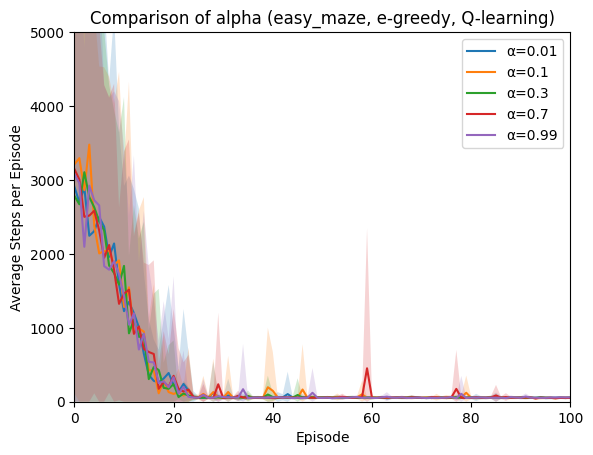

In [17]:
all_data = {}

for a in [0.01, 0.1, 0.3, 0.7, 0.99]:
    all_data[f"α={a}"] = run_multiple_q(easy_maze, early_stop=30000, strategy="e_greedy", eps=0.3, params={"lr": a, "gamma": 0.9}, n_runs=100)

plot_comparison(all_data, "Comparison of alpha (easy_maze, e-greedy, Q-learning)")

As shown in the plot, the five values of α (0.01, 0.1, 0.3, 0.7, 0.99) show very similar convergence behaviour, with all values reaching a low and stable step count within approximately the same number of episodes. This suggests that in the easy maze, the learning rate does not have a significant impact on either convergence speed or final performance.

Theoretically, a higher α means each Q-value update has a larger magnitude, allowing information to propagate faster through the Q-table and leading to faster convergence. A lower α updates more conservatively and requires more episodes to converge, but may produce a more stable Q-table. The occasional spikes visible in the plot are consistent with this, as larger updates can cause temporary instability in the Q-values.

The lack of clear difference between α values is likely due to the simplicity of the easy maze. The environment is straightforward enough that all tested learning rates can find the optimal path within the given number of episodes. In a more complex environment with a larger state space, the effect of α on convergence speed would be more pronounced.

### 2.3 Introducing More Rewards
#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper
#### Question 20

State includes:
| ID  | Location | Holding   | Notes          |
|----:|:---------|:----------|:---------------|
| E0  | Entrance | Nothing   | Starting state |
| Ea  | Entrance | Apples    |                |
| Eb1 | Entrance | 1 Berry   |                |
| Eb2 | Entrance | 2 Berries |                |
| A0  | Aisle    | Nothing   |                |
| Aa  | Aisle    | Apples    |                |
| Ab1 | Aisle    | 1 Berry   |                |
| Ab2 | Aisle    | 2 Berries |                |
| T   | Checkout | -         | Terminal state |

And action includes:
| ID  | Action      | Outcome                       |
|----:|:------------|:------------------------------|
| Fwd | Forward     | Stay(0.1), Forward(0.9)       |
| Bk  | Back        | Stay(0.1), Back(0.9)          |
| Pa  | Pick apple  | Pick apple(1.0)               |
| Pb1 | Pick berry  | Pick berry(1.0)               |
| Pb2 | Pick berry  | Pick berry(0.8), spill(0.2)   |
| Pay | Pay         | Terminal(1.0)                 |

MDP sketch:
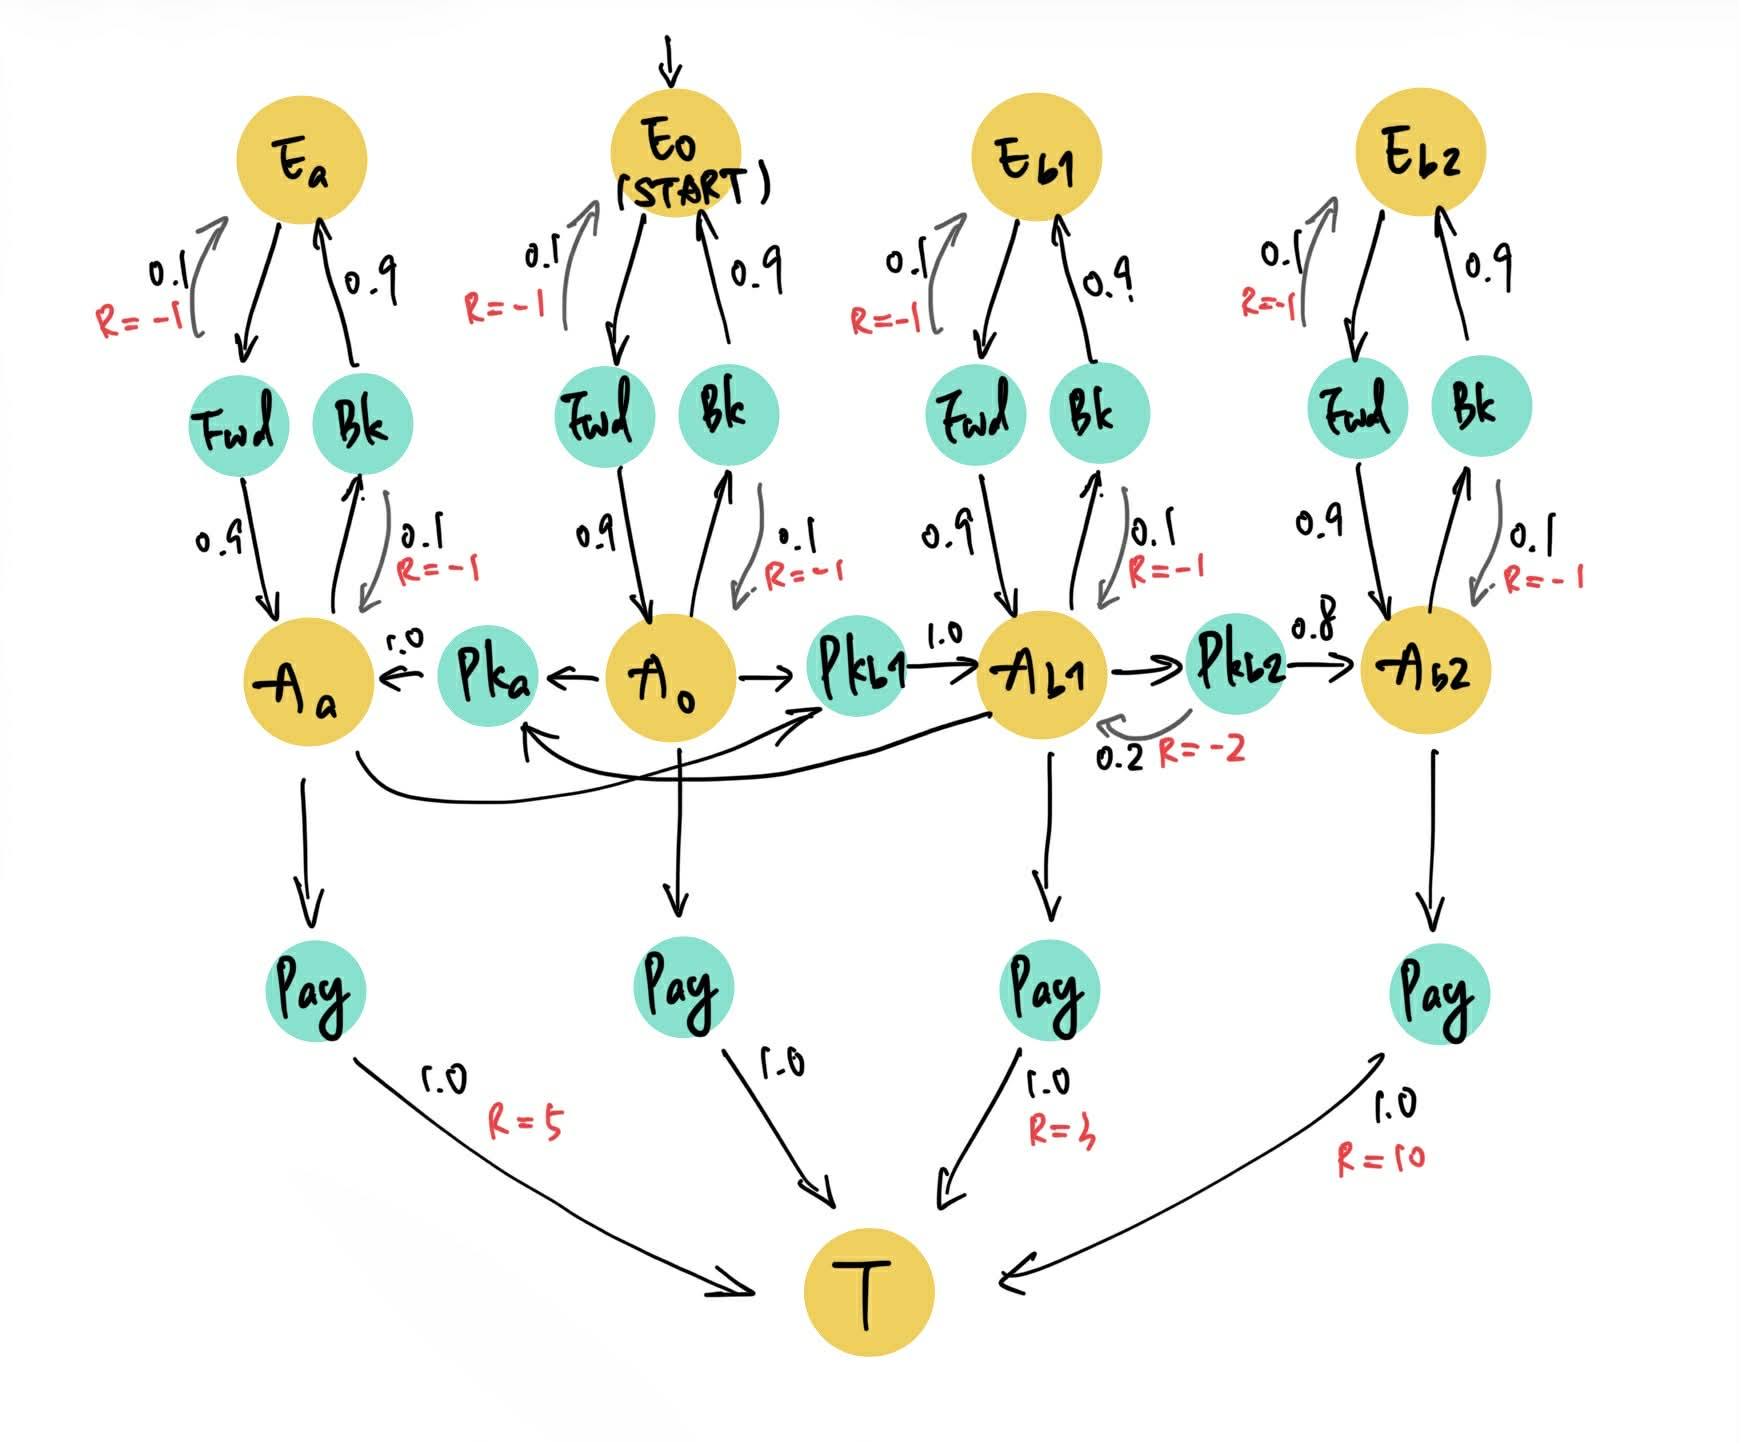

#### Question 21

Policy table:

| $s$   | $a_\pi$        | $v_0(s)$  | $v_1(s)$  | $v_2(s)$  |
|------:|:--------------|:----------|:----------|:----------|
| E0    | Forward       | 0         | -         | -         |
| Ea    | Forward       | 0         | -         | -         |
| Eb1   | Forward       | 0         | -         | -         |
| Eb2   | Forward       | 0         | -         | -         |
| A0    | Pick berry    | 0         | -         | -         |
| Aa    | Pick berry    | 0         | -         | -         |
| Ab1   | Pick berry    | 0         | -         | -         |
| Ab2   | Pay           | 0         | -         | -         |
| T     | -             | 0         | -         | -         |

As in the question, policy actions will be: If agent holds two berrys, pay. If not, pick berry. However, agent cannot pay while locating at entrance, neither can it pick berry. Moving forward to aisle is the only action that makes sense.

$v_0(s) = 0$ for all stats as the terminal has no fucture steps.

Since that, $v_1(s) = \sum_{s'} P(s' \mid s, \pi(s)) \cdot R(s, \pi(s), s')$

And $v_2(s) = \sum_{s'} P(s' \mid s, \pi(s)) \left[ R(s, \pi(s), s') + 0.9\,v_1(s') \right]$

| $s$   | $a_\pi$     | $v_0(s)$ | $v_1(s)$ | $v_2(s)$  |
|------:|:------------|---------:|---------:|----------:|
| E0    | Forward     | 0        | -0.1     | -0.109    |
| Ea    | Forward     | 0        | -0.1     | -0.919    | 
| Eb1   | Forward     | 0        | -0.1     | -0.433    |
| Eb2   | Forward     | 0        | -0.1     | 7.991     |
| A0    | Pick berry  | 0        | 0        | -0.36     |
| Aa    | Pick berry  | 0        | -1       | -1.9      |
| Ab1   | Pick berry  | 0        | -0.4     | 6.728     |
| Ab2   | Pay         | 0        | 10       | 10        |
| T     | -           | 0        | 0        | 0         |

#### Question 22

Getting one box of berrys is dinfinetly not optimal. It yields a lower return than obtaining a bag of apples. Moreover, losing out on the larger payout of two boxes of berries.  As a result, it would not be included in the best course of action because it is dominated by the other two possibilities.

We would examine their long-term predicted discounted return rather than just the immediate benefit to see which is best from the rest two options. This entails taking into account both the transition probabilities and the rewards, as well as the possibility of failing when attempting to gather two boxes of berries. The best course of action is the one that chooses the course of action with the highest projected long-term value, according to Bellman-based reasoning.

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**